In [1]:
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import grad

In [4]:
np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [5]:
data = np.load('burgers_data.npz', allow_pickle=True)

x = data['x']
t = data['t']
u = data['u']

xx, tt = np.meshgrid(x, t, indexing='xy')
xx = xx.reshape(-1, 1)
tt = tt.reshape(-1, 1)

X = np.concatenate([xx, tt], axis=1)
Y = u.T.reshape(-1, 1)

In [6]:
x.shape, t.shape

((128,), (128,))

In [7]:
X.shape, Y.shape

((16384, 2), (16384, 1))

In [8]:
Xic = X[:x.shape[0]]
Yic = Y[:x.shape[0]]

Xf = np.random.permutation(X)

In [9]:
xbc = np.concatenate([np.zeros((x.shape[0], 1)), np.ones((x.shape[0], 1))], axis=0)
tbc = np.tile(t.reshape(-1, 1), (2, 1))

Xbc = np.concatenate([xbc, tbc], axis=1)
Ybc = np.zeros((2*x.shape[0], 1))

Nbc = 2 * t.shape[0]
indx_bc = np.random.choice(2 * t.shape[0], Nbc, replace=False)
Xbc = Xbc[indx_bc]
Ybc = Ybc[indx_bc]

In [10]:
X = torch.tensor(X, dtype=torch.float, device=device)
Y = torch.tensor(Y, dtype=torch.float, device=device)

Xic = torch.tensor(Xic, dtype=torch.float, device=device)
Yic = torch.tensor(Yic, dtype=torch.float, device=device)
Xf= torch.tensor(Xf, dtype=torch.float, device=device)

Xbc = torch.tensor(Xbc, dtype=torch.float, device=device)
Ybc = torch.tensor(Ybc, dtype=torch.float, device=device)

In [11]:
Xdata = [Xic, Xbc]
Ydata = [Yic, Ybc]

In [12]:
class BurgersNonViscidPINN(nn.Module):
  def __init__(self, n_hidden=3, n_neurons=64):
    super().__init__()
    n_in, n_out = (2, 1)
    self.net = nn.Sequential()
    self.net.add_module('In_Linear', nn.Linear(n_in, n_neurons))
    self.net.add_module('In_Tanh', nn.Tanh())
    for l in range(1, n_hidden+1):
      self.net.add_module(f'H_Linear_{l}', nn.Linear(n_neurons, n_neurons))
      self.net.add_module(f'H_Tanh_{l}', nn.Tanh())
    self.net.add_module('Out_Linear', nn.Linear(n_neurons, n_out))

  def forward(self, x):
    return self.net(x)

  def physics_loss(self, x, t, u):
    ut = grad(u, t, create_graph=True, grad_outputs=torch.ones_like(u))[0]
    ux = grad(u, x, create_graph=True, grad_outputs=torch.ones_like(u))[0]
    return ut + u*ux

  def loss(self, Xdata, Ydata, Xf):
    losses = []
    losses.append(F.mse_loss(Ydata[0], self.forward(Xdata[0])))
    losses.append(F.mse_loss(Ydata[1], self.forward(Xdata[1])))
    Xf.requires_grad = True
    x = Xf[:, 0]
    t = Xf[:, 1]
    Xf = torch.stack([x, t], axis=1)
    Yf = self.forward(Xf)[:, 0]
    losses.append(F.mse_loss(self.physics_loss(x, t, Yf), torch.zeros_like(Yf)))
    return losses

In [13]:
model = BurgersNonViscidPINN().to(device)
model

BurgersNonViscidPINN(
  (net): Sequential(
    (In_Linear): Linear(in_features=2, out_features=64, bias=True)
    (In_Tanh): Tanh()
    (H_Linear_1): Linear(in_features=64, out_features=64, bias=True)
    (H_Tanh_1): Tanh()
    (H_Linear_2): Linear(in_features=64, out_features=64, bias=True)
    (H_Tanh_2): Tanh()
    (H_Linear_3): Linear(in_features=64, out_features=64, bias=True)
    (H_Tanh_3): Tanh()
    (Out_Linear): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [15]:
_lambda = 0.25
epochs = 23000

In [16]:
for epoch in range(1, epochs+1):
  model.train()
  losses = model.loss(Xdata, Ydata, Xf)
  loss = (1-_lambda ) * (losses[0] + losses[1]) + _lambda * losses[2]

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 1000 == 0:
    print(f'epoch = {epoch}, loss = {loss}')

epoch = 1000, loss = 0.0004989848239347339
epoch = 2000, loss = 0.0004804501368198544
epoch = 3000, loss = 0.0004730491491500288
epoch = 4000, loss = 0.00044287467608228326
epoch = 5000, loss = 0.00039717304753139615
epoch = 6000, loss = 0.0002837676729541272
epoch = 7000, loss = 6.72751702950336e-05
epoch = 8000, loss = 4.1184051951859146e-05
epoch = 9000, loss = 2.6919487936538644e-05
epoch = 10000, loss = 2.178164868382737e-05
epoch = 11000, loss = 1.405399052600842e-05
epoch = 12000, loss = 1.0810465028043836e-05
epoch = 13000, loss = 8.033501217141747e-06
epoch = 14000, loss = 1.3973398381494917e-05
epoch = 15000, loss = 1.0162904800381511e-05
epoch = 16000, loss = 4.171437467448413e-06
epoch = 17000, loss = 2.0171031792415306e-05
epoch = 18000, loss = 4.109627298021223e-06
epoch = 19000, loss = 3.3412486573070055e-06
epoch = 20000, loss = 7.2202092269435525e-06
epoch = 21000, loss = 2.667510216269875e-06
epoch = 22000, loss = 1.3529148418456316e-05
epoch = 23000, loss = 2.2761103

In [17]:
Y_hat = model(X)

In [18]:
rrmse = torch.sqrt(F.mse_loss(Y, Y_hat)) / torch.norm(Y)
rrmse

tensor(0.0002, device='cuda:0', grad_fn=<DivBackward0>)

In [19]:
Y_hat = Y_hat.reshape(t.shape[0], x.shape[0]).T
Y = Y.reshape(t.shape[0], x.shape[0]).T

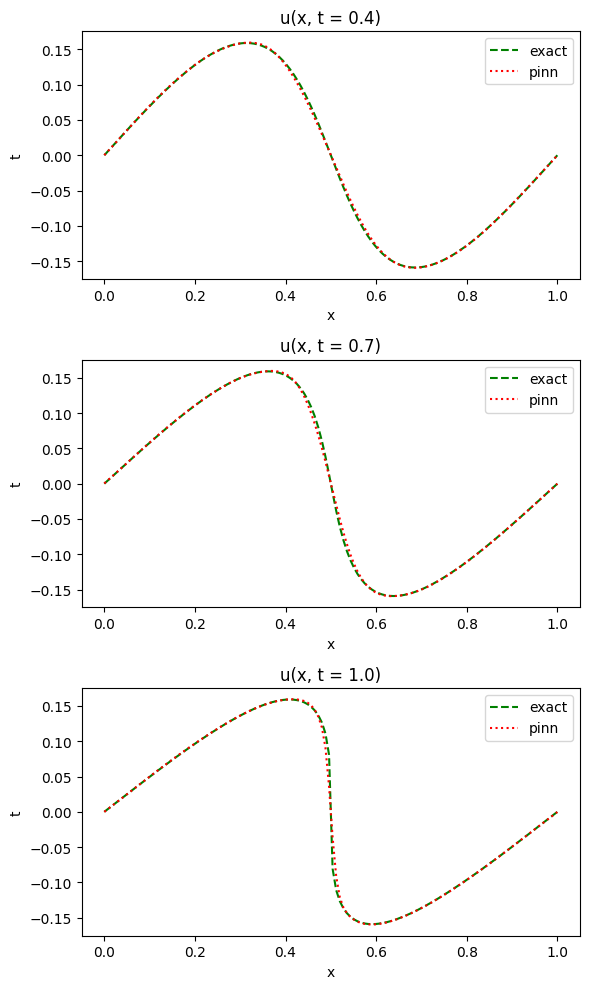

In [20]:
fig, axs = plt.subplots(3, figsize=(6, 10))

for i, j in enumerate(np.searchsorted(t, [0.4, 0.7, 1])):
  y_j = Y[:, j].cpu().numpy()
  y_hat_j = Y_hat[:, j].detach().cpu().numpy()

  axs[i].plot(x, y_j, label='exact', color='green', linestyle='dashed')
  axs[i].plot(x, y_hat_j, label='pinn', color='red', linestyle='dotted')
  axs[i].legend()

  axs[i].set_xlabel('x')
  axs[i].set_ylabel('t')
  axs[i].set_title(f'u(x, t = {round(t[j], 2)})')
plt.savefig('burgers_non_viscid')
plt.tight_layout()

In [21]:
Yhat = model(X)
Yhat_val = Yhat.detach().cpu().numpy()
Yhat_val = Yhat_val.reshape(t.shape[0], x.shape[0]).T

In [22]:
np.savez('solution', x=x, t=t, Yhat_val=Yhat_val)

In [23]:
torch.save(model.state_dict(), 'model')

In [24]:
(x.shape[0], t.shape[0]), (Xic.shape, Yic.shape), (Xbc.shape, Ybc.shape), (X.shape, Xf.shape)

((128, 128),
 (torch.Size([128, 2]), torch.Size([128, 1])),
 (torch.Size([256, 2]), torch.Size([256, 1])),
 (torch.Size([16384, 2]), torch.Size([16384, 2])))